In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the ATS pairs dataset
df = pd.read_csv('/kaggle/input/datasets/arnabnath8201/resume-jd/resume_jd_paired_v2.csv')
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['match_label'].value_counts())
df.head(3)

Loaded: 9700 rows, 4 columns
Columns: ['resume_text', 'job_description', 'match_score', 'match_label']

Label distribution:
match_label
medium    3649
low       3157
high      2894
Name: count, dtype: int64


,resume_text,job_description,match_score,match_label
0,Machine Learning Specialist with 2 years worki...,We are looking for a Senior ML Engineer with a...,0.1806,low
1,MERN Stack Engineer bringing over 7 years of i...,Seeking a skilled Senior iOS/Android Mobile De...,0.6537,medium
2,MERN Stack Engineer bringing over 5 years of i...,Seeking a skilled Mobile Systems App Engineer ...,0.7782,medium


In [3]:
print("Loading BERT model...")
model = SentenceTransformer("all-mpnet-base-v2")

print("Model loaded!")
print("Model:", model._first_module().auto_model.config._name_or_path)
print("Embedding Dimension:", model.get_sentence_embedding_dimension())
print("Max Tokens:", model.max_seq_length)

Loading BERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!
Model: sentence-transformers/all-mpnet-base-v2
Embedding Dimension: 768
Max Tokens: 384


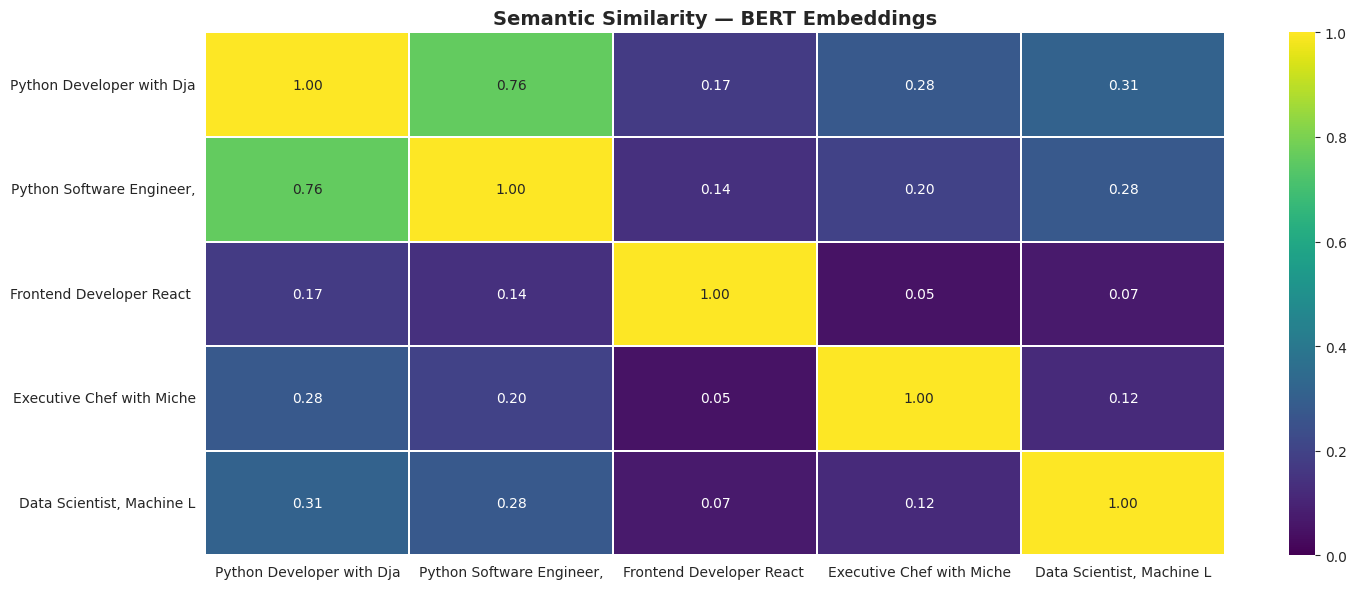

In [4]:
texts = [
    "Python Developer with Django experience",
    "Python Software Engineer, Django REST APIs",
    "Frontend Developer React and JavaScript",
    "Executive Chef with Michelin experience",
    "Data Scientist, Machine Learning, PyTorch",
]

embeddings = model.encode(texts) 
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(15, 6))
sns.heatmap(
    sim_matrix,
    annot=True, fmt='.2f', cmap='viridis',
    xticklabels=[t[:25] for t in texts],
    yticklabels=[t[:25] for t in texts],
    vmin=0, vmax=1,
    linewidth=0.25
)

plt.title(
    'Semantic Similarity — BERT Embeddings',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

In [5]:
#generating resume and jd embeddings
# We embed BOTH resume and job description separately
print("Generating resume embeddings...")
resume_embeddings = model.encode(
    df['resume_text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("\nGenerating job description embeddings...")
jd_embeddings = model.encode(
    df['job_description'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nResume embeddings shape:  {resume_embeddings.shape}")
print(f"JD embeddings shape:      {jd_embeddings.shape}")
print(f"Each text → {resume_embeddings.shape[1]}-dimensional vector")

Generating resume embeddings...


Batches:   0%|          | 0/304 [00:00<?, ?it/s]


Generating job description embeddings...


Batches:   0%|          | 0/304 [00:00<?, ?it/s]


Resume embeddings shape:  (9700, 768)
JD embeddings shape:      (9700, 768)
Each text → 768-dimensional vector


In [6]:
print("Cosine similarity computed for all pairs.")
df['bert_similarity'] = np.diag(
    cosine_similarity(resume_embeddings, jd_embeddings)
)
print(df[['match_label', 'match_score', 'bert_similarity']].head(10))

Cosine similarity computed for all pairs.
  match_label  match_score  bert_similarity
0         low       0.1806         0.778843
1      medium       0.6537         0.603004
2      medium       0.7782         0.626188
3      medium       0.1982         0.725551
4      medium       0.7591         0.479255
5        high       0.9310         0.808895
6         low       0.3309         0.490004
7         low       0.2949         0.299793
8         low       0.1184         0.315974
9      medium       0.6932         0.574400


In [7]:
mae = mean_absolute_error(df['match_score'], df['bert_similarity'])
rmse = np.sqrt(mean_squared_error(df['match_score'], df['bert_similarity']))

print("Base BERT Model Performance (before fine-tuning)")
print("=" * 50)
print(f"  MAE:  {mae:.4f}   (lower is better)")
print(f"  RMSE: {rmse:.4f}   (lower is better)")
print()

Base BERT Model Performance (before fine-tuning)
  MAE:  0.2408   (lower is better)
  RMSE: 0.2901   (lower is better)



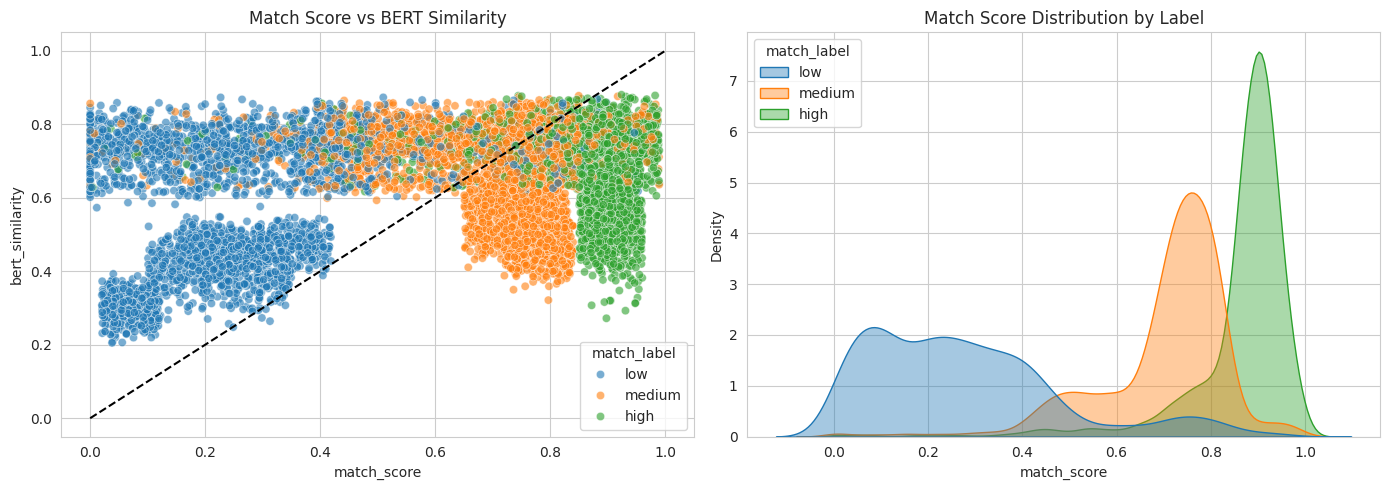

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score vs BERT Similarity
sns.scatterplot(
    data=df,
    x='match_score',
    y='bert_similarity',
    hue='match_label',
    alpha=0.6,
    ax=axes[0]
)

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('Match Score vs BERT Similarity')

# Match Score Distribution by Label
sns.kdeplot(
    data=df,
    x='match_score',
    hue='match_label',
    fill=True,
    common_norm=False,
    alpha=0.4,
    ax=axes[1]
)

axes[1].set_title('Match Score Distribution by Label')

plt.tight_layout()
plt.show()

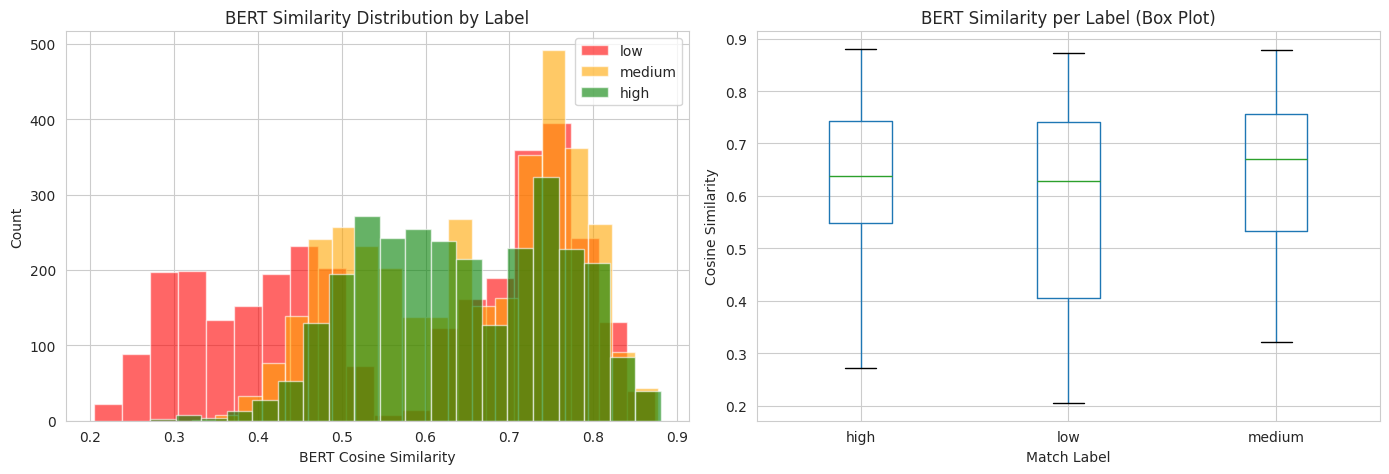


Overlap between labels = base model struggles to separate high vs low matches
Goal of fine-tuning: push these distributions apart


In [9]:
#Similarity Distribution by Label

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: BERT similarity grouped by label
for label, color in [('low','red'), ('medium','orange'), ('high','green')]:
    subset = df[df['match_label'] == label]['bert_similarity']
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color)
axes[0].set_xlabel('BERT Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('BERT Similarity Distribution by Label')
axes[0].legend()

# Box plot
df.boxplot(column='bert_similarity', by='match_label',
           positions=[0,1,2], ax=axes[1])
axes[1].set_title('BERT Similarity per Label (Box Plot)')
axes[1].set_xlabel('Match Label')
axes[1].set_ylabel('Cosine Similarity')
plt.suptitle('')

plt.tight_layout()
plt.show()

# if the distributions overlap heavily, base model can't distinguish
# low vs high matches well → this is WHY we need to fine-tune
print("\nOverlap between labels = base model struggles to separate high vs low matches")
print("Goal of fine-tuning: push these distributions apart")

In [10]:
# Where does the base model make the biggest mistakes?
df['error'] = abs(df['match_score'] - df['bert_similarity'])

print("Average error per label:")
print(df.groupby('match_label')['error'].mean().round(4))
print()

# Show the worst predictions
print("Top 5 worst predictions:")
df.nlargest(5, 'error')[['match_label','match_score','bert_similarity','error']]

Average error per label:
match_label
high      0.2524
low       0.3025
medium    0.1783
Name: error, dtype: float64

Top 5 worst predictions:


,match_label,match_score,bert_similarity,error
8900,medium,0.0000,0.856407,0.856407
2879,low,0.0000,0.845200,0.845200
8918,low,0.0184,0.851002,0.832602
3884,low,0.0000,0.828695,0.828695
203,low,0.0000,0.826791,0.826791


In [12]:
import pickle

with open('resume_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'resume_embeddings': resume_embeddings,
        'jd_embeddings':     jd_embeddings,
        'match_scores':      df['match_score'].tolist(),
        'match_labels':      df['match_label'].tolist(),
    }, f)

print("Saved: resume_embeddings.pkl")
print(f"  resume_embeddings: {resume_embeddings.shape}")
print(f"  jd_embeddings:     {jd_embeddings.shape}")
print()
print("These will be loaded for fine-tuning.")

Saved: resume_embeddings.pkl
  resume_embeddings: (9700, 768)
  jd_embeddings:     (9700, 768)

These will be loaded for fine-tuning.


**Observation**:
The base MPNet model achieves reasonable semantic similarity scores across all categories.

However, *low-match samples exhibit substantially higher* prediction error than medium and high-match samples.

This indicates that the synthetic scoring mechanism incorporates non-semantic factors (e.g., missing skills, experience penalties, injected noise) that are not captured by embedding similarity alone.

* Future improvements may include generating stronger semantic negative pairs and fine-tuning the model on domain-specific ATS data.